This notebooks allows a user to understand whether a certain counties share of vote was effected by something the leading party did, where a synthetic control is created and the results are compared

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
from scipy.optimize import nnls
import matplotlib.pyplot as plt

In [2]:
pdf_results = pd.read_csv("data/input/election_results/general_election_results.csv")

In [3]:


def prepare_all_county(pdf: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare vote share data by County and Year.
    Returns party vote percentages and total votes.
    """

    # Pivot votes by County + Year
    pdf_votes = (
        pdf.query("Country == 'England'").query("Geography == 'County'")[["County", "Year", "Party", "Votes"]]
        .pivot_table(
            index=["County", "Year"],
            columns="Party",
            values="Votes",
            aggfunc="sum",
        )
        .reset_index()
    )

    # Identify party columns
    party_cols = pdf_votes.columns.difference(["County", "Year"])

    # Total votes per County-Year
    pdf_votes["Total_Votes"] = pdf_votes[party_cols].sum(axis=1)

    # Convert to percentages
    pdf_votes_pct = pdf_votes.copy()
    pdf_votes_pct[party_cols] = (
        pdf_votes_pct[party_cols]
        .div(pdf_votes_pct["Total_Votes"], axis=0)
        .mul(100)
    )

    return pdf_votes_pct[["County", "Year", "Conservative", "Labour", "Liberal Democrats", 'Green Party', 'Reform UK']].fillna(0)


In [4]:
pdf_all = pdf_results.pipe(prepare_all_county)

In [5]:
START_YEAR = 1945

In [6]:
#HS2 Cancellation + Local Lockdown
TREATMENT_YEAR = 2023
TREATED_UNIT = "Greater Manchester"
PARTY = "Conservative"

# In Manchester Tories dropped 54% whilst in UK it dropped 47%

In [7]:
pdf_wide = (
    pdf_all
    .pivot(index="Year", columns="County", values=PARTY)
    .sort_index()
)

# Filter years
pdf_post = pdf_wide.loc[pdf_wide.index >= START_YEAR]

# Keep only complete counties
complete_counties = pdf_post.columns[pdf_post.notna().all()]
pdf_wide = pdf_post[complete_counties]

In [8]:
#Prepare Data
Y_treated = pdf_wide[TREATED_UNIT]
Y_donors = pdf_wide.drop(columns=TREATED_UNIT)

pre_period = pdf_wide.index < TREATMENT_YEAR

Y_treated_pre = Y_treated.loc[pre_period]
Y_donors_pre = Y_donors.loc[pre_period]

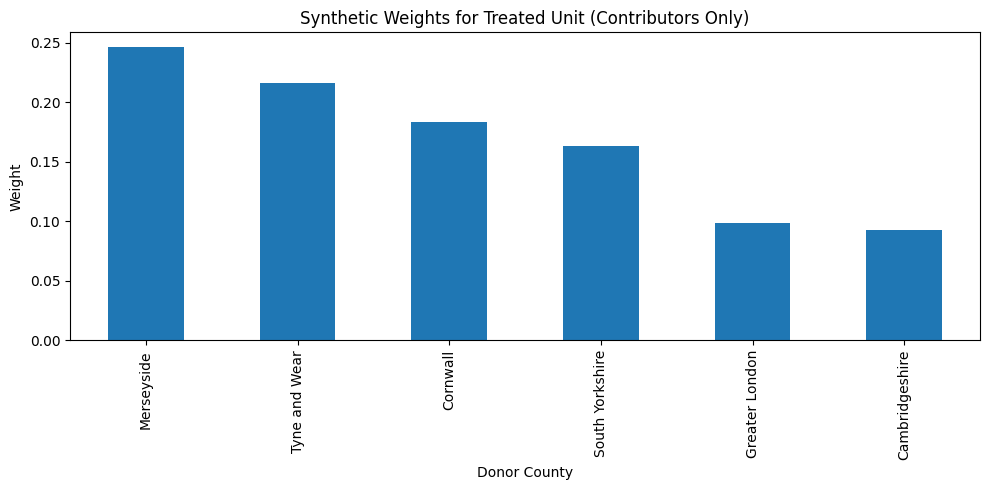

In [15]:
#Synethetic Control
X = Y_donors_pre.values
y = Y_treated_pre.values

weights, _ = nnls(X, y)

if weights.sum() == 0:
    raise ValueError("NNLS failed: all weights are zero")

weights = weights / weights.sum()
weights = pd.Series(weights, index=Y_donors_pre.columns)

Y_synthetic = Y_donors.dot(weights)
treatment_effect = Y_treated - Y_synthetic

# Show only nonzero synthetic weights as a bar chart
contributing_weights = weights[weights > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 5))
contributing_weights.plot(kind='bar')
plt.title('Synthetic Weights for Treated Unit (Contributors Only)')
plt.ylabel('Weight')
plt.xlabel('Donor County')
plt.tight_layout()
plt.show()

In [10]:
#TODO - Filter out placebos with very bad pre-treatment fit

#Placebo Tests
placebo_effects = {}

for placebo_unit in pdf_wide.columns:
    if placebo_unit == TREATED_UNIT:
        continue

    Y_treated_p = pdf_wide[placebo_unit]
    Y_donors_p = pdf_wide.drop(columns=placebo_unit)

    pre_period_p = pdf_wide.index < TREATMENT_YEAR

    Y_treated_pre_p = Y_treated_p.loc[pre_period_p]
    Y_donors_pre_p = Y_donors_p.loc[pre_period_p]

    X_p = Y_donors_pre_p.values
    y_p = Y_treated_pre_p.values

    weights_p, _ = nnls(X_p, y_p)

    if weights_p.sum() == 0:
        continue

    weights_p = weights_p / weights_p.sum()
    weights_p = pd.Series(weights_p, index=Y_donors_pre_p.columns)

    Y_synth_p = Y_donors_p.dot(weights_p)
    effect_p = Y_treated_p - Y_synth_p

    placebo_effects[placebo_unit] = effect_p

print(f"\nGenerated {len(placebo_effects)} placebo series")


Generated 40 placebo series


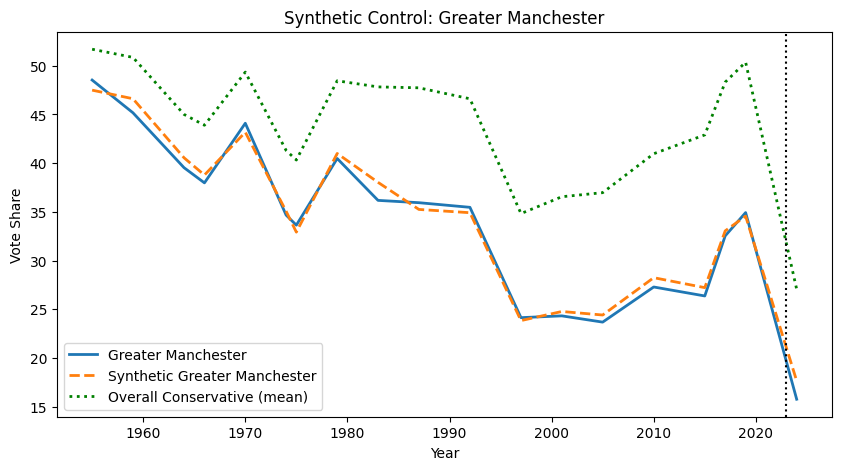

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(Y_treated, label=TREATED_UNIT, linewidth=2)
plt.plot(Y_synthetic, label=f"Synthetic {TREATED_UNIT}", linestyle="--", linewidth=2)

# Calculate and plot overall Conservative vote share across all counties for each year
overall_con_vote_share = pdf_wide.mean(axis=1)
plt.plot(overall_con_vote_share, label='Overall Conservative (mean)', linestyle=':', linewidth=2, color='green')

plt.axvline(TREATMENT_YEAR, color="black", linestyle=":")
plt.legend()
plt.title(f"Synthetic Control: {TREATED_UNIT}")
plt.ylabel("Vote Share")
plt.xlabel("Year")
plt.show()

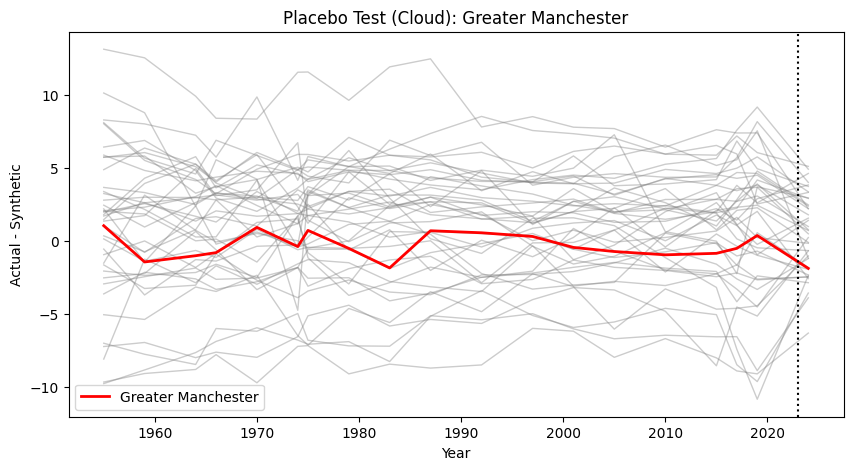

In [12]:


plt.figure(figsize=(10, 5))

# Grey cloud
for eff in placebo_effects.values():
    plt.plot(eff.index, eff.values, color="grey", alpha=0.4, linewidth=1)

# Treated effect
plt.plot(
    treatment_effect.index,
    treatment_effect.values,
    color="red",
    linewidth=2,
    label=TREATED_UNIT
)

plt.axvline(TREATMENT_YEAR, color="black", linestyle=":")
plt.legend()
plt.title(f"Placebo Test (Cloud): {TREATED_UNIT}")
plt.ylabel("Actual - Synthetic")
plt.xlabel("Year")
plt.show()

For Greater Manchester this is within the range of the cloud so there's no evidence of big difference